In [50]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn 
import torch .optim as optim
import matplotlib.pyplot as plt

In [51]:
torch.manual_seed(42)

In [52]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using devide: {device}")

Using devide: cuda


In [53]:
df = pd.read_csv('fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


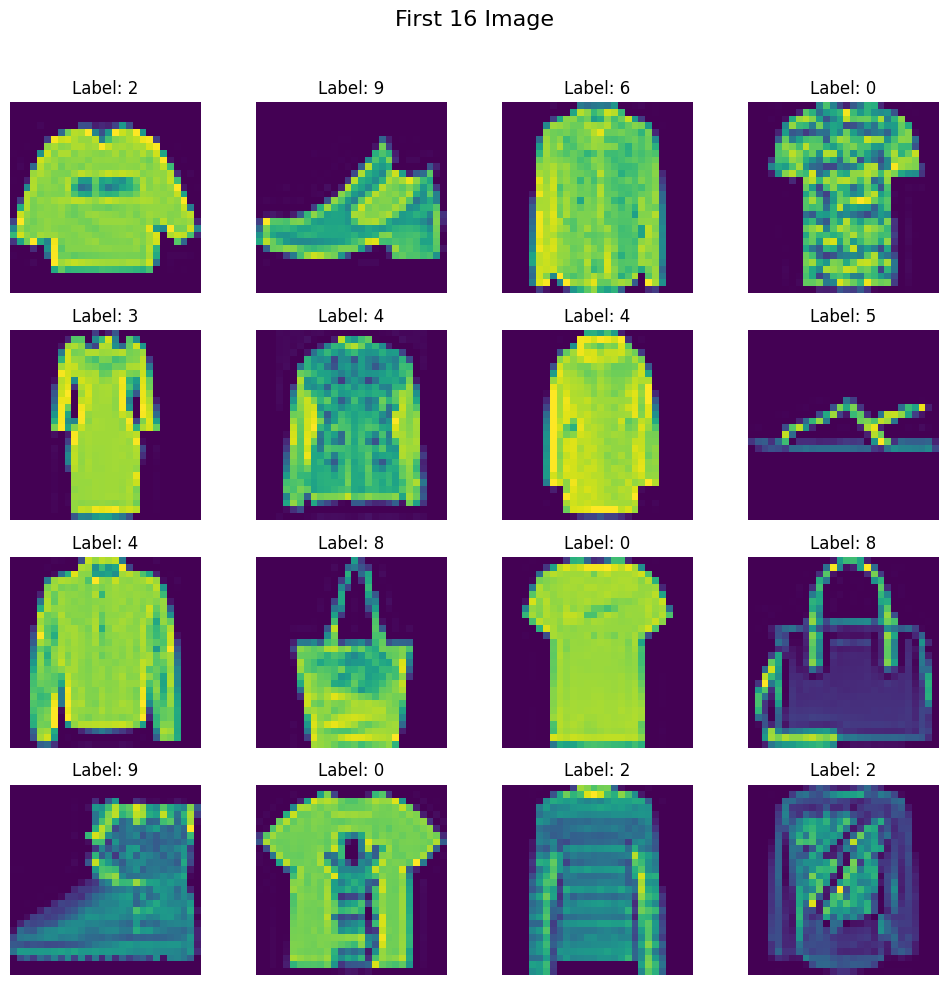

In [54]:
fig ,axes = plt.subplots(4,4, figsize=(10,10))
fig.suptitle("First 16 Image", fontsize=16)

for i, ax in enumerate(axes.flat):
    img = df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {df.iloc[i,0]}")

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [55]:
X = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [56]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [58]:
from torchvision.transforms import transforms

custom_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(244),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std =[0.229,0.224,0.225])
])

In [86]:
from PIL import Image
import numpy as np

class CustomDataset(Dataset):

    def __init__(self,features,labels,transforms):
        self.features = features
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.features)

    def __getitem__(self,index):
        image = self.features[index].reshape(28,28)

        image = image.astype(np.uint8)

        #iwant in (h,w,c) not in (c,h,w)
        image = np.stack([image]*3, axis=-1)

        image = Image.fromarray(image)

        image = self.transforms(image)

        return image, torch.tensor(self.labels[index], dtype=torch.long)
        

In [87]:
train_dataset = CustomDataset(X_train,y_train,transforms=custom_transform)

In [88]:
len(train_dataset)

48000

In [89]:
test_dataset = CustomDataset(X_test,y_test,transforms=custom_transform)

In [90]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [91]:
import torchvision.models as models

vgg16 = models.vgg16(pretrained=True)

In [92]:
for param in vgg16.features.parameters():
    param.requires_grad=False

In [93]:
vgg16.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [94]:
vgg16.classifier = nn.Sequential(
    nn.Linear(25088,1024),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(1024,512),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(512,10)
)

In [95]:
vgg16 = vgg16.to(device)

In [96]:
learning_rate = 0.001
epochs = 10

In [97]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16.classifier.parameters(),lr=learning_rate)

In [98]:
for epoch in range(epochs):

    total_epoch_loss = 0
    for batch_features, batch_labels in train_loader:

        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        outputs = vgg16(batch_features)
        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_epoch_loss = total_epoch_loss + loss.item()

    avg_loss = total_epoch_loss/len(train_loader)
    print(f'Epoch: {epoch+1}, Loss: {avg_loss}')

Epoch: 1, Loss: 0.44058949465304614
Epoch: 2, Loss: 0.33686229498187703
Epoch: 3, Loss: 0.30541193464833
Epoch: 4, Loss: 0.2847315723504871
Epoch: 5, Loss: 0.26348213048372415
Epoch: 6, Loss: 0.24389290169564387
Epoch: 7, Loss: 0.23470617416446718
Epoch: 8, Loss: 0.22417170057221664
Epoch: 9, Loss: 0.20737235466309356
Epoch: 10, Loss: 0.20877568433829582


In [99]:
model.eval()

MYNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [100]:
total = 0
correct = 0

with torch.no_grad():

    for batch_features,batch_labels in test_loader:

        batch_features, batch_labels = batch_features.to(device),batch_labels.to(device)
        
        output = vgg16(batch_features)

        _, predicted = torch.max(output,1)

        total = total + batch_labels.shape[0]

        correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.8996666666666666
